# Induced Seismicity Analysis

Analysis notebook for newly added induced seismicity datasets:

- Prefer registered catalogs: `<DATASET>-Standard` / `<DATASET>`
- Strict catalog loading only: no fallback to `InducedTripletBase`; unregistered datasets raise errors
- Supports both single-dataset analysis and multi-dataset batch comparison

## 1) Setup

In [23]:
from __future__ import annotations

import sys
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from scipy.signal import find_peaks, peak_widths


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / 'src').exists() and (candidate / 'data').exists():
            return candidate
    raise FileNotFoundError("Cannot find project root containing both 'src' and 'data'.")


PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import src
import src.data.catalog as catalog
import src.catalogs as catalogs

pd.options.display.max_columns = 120
print(f'PROJECT_ROOT: {PROJECT_ROOT}')

PROJECT_ROOT: /root/autodl-tmp/em_eqf


## 2) Dataset Discovery

In [24]:
def discover_processed_triplet_datasets(data_root: Path) -> list[str]:
    datasets: list[str] = []
    for d in sorted(data_root.iterdir()):
        if not d.is_dir():
            continue
        name = d.name
        summary_path = d / 'processed' / f'{name}_summary.json'
        eq_path = d / 'processed' / f'{name}_eq_processed.csv'
        if summary_path.exists() and eq_path.exists():
            datasets.append(name)
    return datasets


triplet_datasets = discover_processed_triplet_datasets(PROJECT_ROOT / 'data')
registered_datasets = sorted([x for x in catalog.Catalog.list_available() if x.endswith('-Standard')])

print(f'Discovered processed triplet datasets ({len(triplet_datasets)}):')
print(triplet_datasets)
print(f"Registered '*-Standard' catalogs ({len(registered_datasets)}):")
print(registered_datasets)

Discovered processed triplet datasets (12):
['Basel', 'CB_HAB1a', 'CB_HAB1b', 'CB_HAB4', 'FORGE2022', 'SSFS1993', 'SSFS2000', 'SSFS2003', 'SSFS2004', 'SSFS2005', 'St1-2018', 'St1-2020']
Registered '*-Standard' catalogs (26):
['AZDX-Standard', 'Basel-Standard', 'CB_HAB1a-Standard', 'CB_HAB1b-Standard', 'CB_HAB4-Standard', 'ChinaArray-Standard', 'ChuanDian-Standard', 'CooperBasin-Standard', 'FORGE2022-Standard', 'Geysers-Standard', 'Hauksson-Standard', 'PNR-Standard', 'PNR_1z-Standard', 'PNR_2-Standard', 'QTMSaltonSea-Standard', 'QTMSanJacinto-Standard', 'SCEDC-Standard', 'SSFS-Standard', 'SSFS1993-Standard', 'SSFS2000-Standard', 'SSFS2003-Standard', 'SSFS2004-Standard', 'SSFS2005-Standard', 'St1-2018-Standard', 'St1-2020-Standard', 'White-Standard']


## 3) Flexible Catalog Loader

In [26]:
REGION_ALIASES = {
    'ssfs': 'SSFS',
    'cb': 'CooperBasin',
    'cooperbasin': 'CooperBasin',
    'cooper_basin': 'CooperBasin',
    'cooper-basin': 'CooperBasin',
}
REGION_MEMBERS = {
    'SSFS': ['SSFS1993', 'SSFS2000', 'SSFS2003', 'SSFS2004', 'SSFS2005'],
    'CooperBasin': ['CB_HAB1a', 'CB_HAB1b', 'CB_HAB4'],
}


def normalize_dataset_name(dataset: str) -> str:
    token = str(dataset).strip()
    if not token:
        raise ValueError('dataset cannot be empty.')
    token_l = token.lower()
    return REGION_ALIASES[token_l] if token_l in REGION_ALIASES else token


def resolve_dataset_tokens(
    datasets: list[str],
    expand_region_members: bool = False,
) -> list[str]:
    resolved: list[str] = []
    for token in datasets:
        canonical = normalize_dataset_name(token)
        if expand_region_members and canonical in REGION_MEMBERS:
            resolved.extend(REGION_MEMBERS[canonical])
        else:
            resolved.append(canonical)

    deduped: list[str] = []
    seen: set[str] = set()
    for name in resolved:
        if name in seen:
            continue
        deduped.append(name)
        seen.add(name)
    return deduped


def load_catalog_flexible(dataset: str, catalog_cfg: dict[str, Any] | None = None):
    raw_dataset = str(dataset)
    dataset = normalize_dataset_name(raw_dataset)
    if dataset != raw_dataset:
        print(f'Resolved dataset alias: {raw_dataset!r} -> {dataset!r}')

    from src.utils.tpp_experiments import load_tpp_catalog

    ds, registry_name, _ = load_tpp_catalog(
        dataset,
        base_dir=PROJECT_ROOT / 'data' / dataset,
        catalog_cfg=catalog_cfg,
        candidates=[f'{dataset}-Standard', dataset],
    )
    print(f'Using registered catalog: {registry_name}')
    return ds


## 4) Series / Peak / Plot Helpers

In [27]:
def extract_injection_count_series(seq, metadata: dict[str, Any] | None = None) -> dict[str, Any]:
    if metadata is None:
        raise ValueError('metadata is required to build absolute timestamp axis.')
    if 'time_series' not in seq or 'time_series_times' not in seq:
        raise ValueError('Selected sequence has no time_series/time_series_times.')

    injection = seq.time_series.squeeze().detach().cpu().numpy()
    inj_time = seq.time_series_times.squeeze().detach().cpu().numpy()
    arrival_times = seq.arrival_times.detach().cpu().numpy()

    injection = np.asarray(injection).reshape(-1)
    inj_time = np.asarray(inj_time).reshape(-1)
    arrival_times = np.asarray(arrival_times).reshape(-1)

    if inj_time.shape[0] < 2:
        raise ValueError('time_series_times must contain at least 2 samples.')
    if injection.shape[0] != inj_time.shape[0]:
        raise ValueError(
            'time_series and time_series_times must have same length, got '
            f'{injection.shape[0]} vs {inj_time.shape[0]}'
        )

    bin_counts, _ = np.histogram(arrival_times, bins=inj_time)
    injection_mid = 0.5 * (injection[1:] + injection[:-1])
    inj_time_mid = 0.5 * (inj_time[1:] + inj_time[:-1])

    out: dict[str, Any] = {
        'injection': injection,
        'inj_time': inj_time,
        'injection_mid': injection_mid,
        'inj_time_mid': inj_time_mid,
        'arrival_times': arrival_times,
        'bin_counts': bin_counts,
        'inj_time_mid_ts': _build_absolute_time_axis(inj_time_mid, metadata),
    }

    return out


def _build_absolute_time_axis(
    rel_time: np.ndarray,
    metadata: dict[str, Any],
) -> pd.DatetimeIndex:
    required_md = ('start_ts', 'freq')
    missing_md = [k for k in required_md if k not in metadata]
    if missing_md:
        raise KeyError(f'Missing required metadata keys for timestamp axis: {missing_md}')

    start_ts = pd.Timestamp(metadata['start_ts'])
    if pd.isna(start_ts):
        raise ValueError(f"Invalid metadata['start_ts']: {metadata['start_ts']!r}")
    if start_ts.tz is not None:
        start_ts = start_ts.tz_convert('UTC').tz_localize(None)

    freq_td = pd.to_timedelta(metadata['freq'])
    if pd.isna(freq_td) or freq_td <= pd.Timedelta(0):
        raise ValueError(f"Invalid metadata['freq']: {metadata['freq']!r}")

    rel = np.asarray(rel_time, dtype=float).reshape(-1)
    if not np.isfinite(rel).all():
        bad = np.where(~np.isfinite(rel))[0][:10].tolist()
        raise ValueError(f'Found non-finite relative times at rows {bad}.')

    delta = pd.to_timedelta(rel * freq_td.total_seconds(), unit='s')
    return pd.DatetimeIndex(start_ts + delta)


def _resolve_plot_x(
    series: dict[str, Any],
    metadata: dict[str, Any] | None = None,
) -> tuple[pd.DatetimeIndex, str, bool]:
    if 'inj_time_mid_ts' in series:
        x_ts = pd.DatetimeIndex(series['inj_time_mid_ts'])
        return x_ts, 'Time (timestamp)', True

    if metadata is None:
        raise ValueError("Missing 'inj_time_mid_ts' and metadata is None.")

    if 'inj_time_mid' not in series:
        raise KeyError("Missing 'inj_time_mid' in series.")

    x_ts = _build_absolute_time_axis(series['inj_time_mid'], metadata)
    return x_ts, 'Time (timestamp)', True


def _apply_timestamp_axis(ax) -> None:
    locator = mdates.AutoDateLocator()
    formatter = mdates.ConciseDateFormatter(locator)
    formatter.formats = ['%Y', '%Y-%m', '%m-%d', '%H:%M', '%H:%M', '%S']
    formatter.zero_formats = ['', '%Y', '%Y-%m', '%m-%d', '%H:%M', '%H:%M']
    formatter.offset_formats = ['', '%Y', '%Y-%m', '%Y-%m-%d', '%Y-%m-%d', '%Y-%m-%d %H:%M']
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)
    ax.tick_params(axis='x', labelrotation=0)



def detect_peaks(
    injection_mid: np.ndarray,
    peak_height: float = 0.5,
    peak_min_distance: int = 60,
) -> dict[str, np.ndarray]:
    peaks_idx, props = find_peaks(
        injection_mid,
        height=peak_height,
        distance=peak_min_distance,
    )

    if 'peak_heights' not in props:
        raise KeyError("find_peaks result missing 'peak_heights'.")

    widths, width_heights, left_bases_float, right_bases_float = peak_widths(
        x=injection_mid,
        peaks=peaks_idx,
        rel_height=1,
    )

    left_bases = np.round(left_bases_float).astype(int)
    right_bases = np.round(right_bases_float).astype(int)

    return {
        'peaks_idx': peaks_idx,
        'peak_heights': np.asarray(props['peak_heights']),
        'widths': widths,
        'width_heights': width_heights,
        'left_bases': left_bases,
        'right_bases': right_bases,
    }


def plot_global_overlay(
    dataset: str,
    series: dict[str, Any],
    metadata: dict[str, Any] | None = None,
    save_path: Path | None = None,
    show: bool = True,
    dpi: int = 150,
) -> Path | None:
    x, x_label, is_timestamp = _resolve_plot_x(series, metadata=metadata)
    injection_mid = series['injection_mid']
    bin_counts = series['bin_counts']

    fig, ax1 = plt.subplots(figsize=(12, 4))
    l1 = ax1.plot(x, injection_mid, color='tab:blue', linewidth=0.8, label='Injection Rate')
    ax1.set_xlabel(x_label)
    ax1.set_ylabel('Injection Rate', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.grid(alpha=0.3)

    ax2 = ax1.twinx()
    l2 = ax2.plot(x, bin_counts, color='tab:orange', linewidth=0.8, label='Event Count')
    ax2.set_ylabel('Event Count', color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')

    lines = l1 + l2
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc='upper right')

    if is_timestamp:
        _apply_timestamp_axis(ax1)

    fig.suptitle(f'{dataset}: Injection vs Event Count')
    fig.tight_layout()

    saved: Path | None = None
    if save_path is not None:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=dpi, bbox_inches='tight')
        saved = save_path

    if show:
        plt.show()
    else:
        plt.close(fig)

    return saved



def plot_peak_window(
    dataset: str,
    series: dict[str, Any],
    peaks: dict[str, np.ndarray],
    peak_rank: int = 0,
    offset: int = 50,
    metadata: dict[str, Any] | None = None,
    save_path: Path | None = None,
    show: bool = True,
    dpi: int = 150,
) -> Path | None:
    peaks_idx = peaks['peaks_idx']
    left = peaks['left_bases']
    right = peaks['right_bases']

    if len(peaks_idx) == 0:
        print(f'{dataset}: no peaks found with current thresholds.')
        return None
    if peak_rank < 0 or peak_rank >= len(peaks_idx):
        raise IndexError(f'peak_rank={peak_rank} out of range [0, {len(peaks_idx)-1}]')

    x, x_label, is_timestamp = _resolve_plot_x(series, metadata=metadata)
    injection_mid = series['injection_mid']
    bin_counts = series['bin_counts']

    lb = int(left[peak_rank])
    rb = int(right[peak_rank])
    start = max(0, lb - offset)
    end = min(len(injection_mid), rb + offset)

    fig, ax1 = plt.subplots(figsize=(12, 4))
    l1 = ax1.plot(x[start:end], injection_mid[start:end], color='tab:blue', label='Injection Rate', linewidth=0.8)
    ax1.set_xlabel(x_label)
    ax1.set_ylabel('Injection Rate', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.grid(alpha=0.3)

    ax2 = ax1.twinx()
    l2 = ax2.plot(x[start:end], bin_counts[start:end], color='tab:orange', label='Event Count', linewidth=0.8)
    ax2.set_ylabel('Event Count', color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')

    ax1.axvline(x[lb], color='green', linestyle='--', label='left_base')
    ax1.axvline(x[rb], color='red', linestyle='--', label='right_base')

    peak_idx = int(peaks_idx[peak_rank])
    ax1.plot(x[peak_idx], injection_mid[peak_idx], 'o', color='black', label='peak')

    lines = l1 + l2 + ax1.lines[-3:]
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc='upper right')

    if is_timestamp:
        _apply_timestamp_axis(ax1)

    fig.suptitle(f'{dataset}: peak#{peak_rank} window [{start}, {end})')
    fig.tight_layout()

    saved: Path | None = None
    if save_path is not None:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=dpi, bbox_inches='tight')
        saved = save_path

    if show:
        plt.show()
    else:
        plt.close(fig)

    return saved



def summarize_catalog(dataset: str, catalog_ds, series: dict[str, np.ndarray], peaks: dict[str, np.ndarray]) -> dict[str, Any]:
    seq = catalog_ds.full_sequence
    md = catalog_ds.metadata
    required_md = ('name', 'freq', 'mag_completeness')
    missing_md = [k for k in required_md if k not in md]
    if missing_md:
        raise KeyError(f'Missing required metadata keys in catalog: {missing_md}')

    injection_sum = float(series['injection_mid'].sum())
    count_sum = float(series['bin_counts'].sum())
    ratio = count_sum / injection_sum if injection_sum > 0 else np.nan

    return {
        'dataset': dataset,
        'catalog_name': md['name'],
        'freq': md['freq'],
        'n_events': int(len(seq)),
        'duration': float(seq.t_end - seq.t_start),
        'injection_sum': injection_sum,
        'count_sum': count_sum,
        'count_to_injection_ratio': float(ratio),
        'n_peaks': int(len(peaks['peaks_idx'])),
        'mag_completeness': float(md['mag_completeness']),
    }


def compare_datasets(
    datasets: list[str],
    catalog_cfg: dict[str, Any] | None = None,
    peak_height: float = 0.5,
    peak_min_distance: int = 60,
) -> tuple[pd.DataFrame, dict[str, dict[str, Any]]]:
    rows: list[dict[str, Any]] = []
    cache: dict[str, dict[str, Any]] = {}

    for ds_name in datasets:
        cat_ds = load_catalog_flexible(ds_name, catalog_cfg)
        series = extract_injection_count_series(cat_ds.full_sequence, metadata=cat_ds.metadata)
        peaks = detect_peaks(
            injection_mid=series['injection_mid'],
            peak_height=peak_height,
            peak_min_distance=peak_min_distance,
        )
        rows.append(summarize_catalog(ds_name, cat_ds, series, peaks))
        cache[ds_name] = {'catalog': cat_ds, 'series': series, 'peaks': peaks}

    df = pd.DataFrame(rows)
    df = df.sort_values('n_events', ascending=False).reset_index(drop=True)
    return df, cache

def export_triplet_plots(
    datasets: list[str],
    catalog_cfg: dict[str, Any] | None = None,
    peak_height: float = 0.5,
    peak_min_distance: int = 60,
    peak_rank: int = 0,
    offset: int = 60,
    output_subdir: str = 'analysis_plots',
    dpi: int = 150,
) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []

    for ds_name in datasets:
        resolved = normalize_dataset_name(ds_name)
        cat_ds = load_catalog_flexible(resolved, catalog_cfg)
        series = extract_injection_count_series(cat_ds.full_sequence, metadata=cat_ds.metadata)
        peaks = detect_peaks(
            injection_mid=series['injection_mid'],
            peak_height=peak_height,
            peak_min_distance=peak_min_distance,
        )

        out_dir = PROJECT_ROOT / 'data' / resolved / output_subdir
        out_dir.mkdir(parents=True, exist_ok=True)

        global_path = out_dir / f'{resolved}_global_overlay.png'
        peak_path = out_dir / f'{resolved}_peak_rank{peak_rank}_offset{offset}.png'
        mag_dist_path = out_dir / f'{resolved}_magnitude_distribution.png'

        saved_global = plot_global_overlay(
            resolved,
            series,
            metadata=cat_ds.metadata,
            save_path=global_path,
            show=False,
            dpi=dpi,
        )
        saved_peak = plot_peak_window(
            resolved,
            series,
            peaks,
            peak_rank=peak_rank,
            offset=offset,
            metadata=cat_ds.metadata,
            save_path=peak_path,
            show=False,
            dpi=dpi,
        )

        m = cat_ds.full_sequence.mag
        mags = m.detach().cpu().numpy().reshape(-1) if hasattr(m, 'detach') else np.asarray(m).reshape(-1)
        mags = mags[np.isfinite(mags)]

        saved_mag_dist = None
        if mags.size > 0:
            bin_width = 0.1
            bins = np.arange(np.floor(mags.min()), np.ceil(mags.max()) + bin_width, bin_width)
            if bins.size < 2:
                bins = np.array([mags.min() - 0.05, mags.max() + 0.05])

            fig, ax = plt.subplots(figsize=(7, 4))
            ax.hist(mags, bins=bins, color='tab:blue', edgecolor='black', alpha=0.8)
            ax.set_xlabel('Magnitude')
            ax.set_ylabel('Count')
            ax.set_title('Magnitude Distribution for ' + resolved)
            ax.grid(alpha=0.3)
            fig.tight_layout()
            fig.savefig(mag_dist_path, dpi=dpi, bbox_inches='tight')
            plt.close(fig)
            saved_mag_dist = mag_dist_path

        rows.append({
            'dataset': resolved,
            'n_peaks': int(len(peaks['peaks_idx'])),
            'global_plot': str(saved_global.relative_to(PROJECT_ROOT)) if saved_global is not None else None,
            'peak_plot': str(saved_peak.relative_to(PROJECT_ROOT)) if saved_peak is not None else None,
            'magnitude_distribution_plot': str(saved_mag_dist.relative_to(PROJECT_ROOT)) if saved_mag_dist is not None else None,
            'output_dir': str(out_dir.relative_to(PROJECT_ROOT)),
        })

    return pd.DataFrame(rows)


## 5) Single Dataset Analysis

In [28]:
registered_datasets

['AZDX-Standard',
 'Basel-Standard',
 'CB_HAB1a-Standard',
 'CB_HAB1b-Standard',
 'CB_HAB4-Standard',
 'ChinaArray-Standard',
 'ChuanDian-Standard',
 'CooperBasin-Standard',
 'FORGE2022-Standard',
 'Geysers-Standard',
 'Hauksson-Standard',
 'PNR-Standard',
 'PNR_1z-Standard',
 'PNR_2-Standard',
 'QTMSaltonSea-Standard',
 'QTMSanJacinto-Standard',
 'SCEDC-Standard',
 'SSFS-Standard',
 'SSFS1993-Standard',
 'SSFS2000-Standard',
 'SSFS2003-Standard',
 'SSFS2004-Standard',
 'SSFS2005-Standard',
 'St1-2018-Standard',
 'St1-2020-Standard',
 'White-Standard']

In [29]:
DATASET ='CB_HAB1b' # 'cb'  
CATALOG_CFG = {
    'mag_completeness': -2,
    'normalize': True,
    # 'end_ts': "2018-8-21T23:59:59",
}
PEAK_HEIGHT = 0.5
PEAK_MIN_DISTANCE = 60

RESOLVED_DATASET = normalize_dataset_name(DATASET)
print(f'Selected dataset: {DATASET!r} -> {RESOLVED_DATASET!r}')

catalog_ds = load_catalog_flexible(DATASET, CATALOG_CFG)
series = extract_injection_count_series(catalog_ds.full_sequence, metadata=catalog_ds.metadata)
peaks = detect_peaks(
    injection_mid=series['injection_mid'],
    peak_height=PEAK_HEIGHT,
    peak_min_distance=PEAK_MIN_DISTANCE,
)

single_summary = summarize_catalog(
    dataset=RESOLVED_DATASET,
    catalog_ds=catalog_ds,
    series=series,
    peaks=peaks,
)
single_summary

Selected dataset: 'CB_HAB1b' -> 'CB_HAB1b'
Using registered catalog: CB_HAB1b-Standard


{'dataset': 'CB_HAB1b',
 'catalog_name': 'CB_HAB1b',
 'freq': '1h',
 'n_events': 8282,
 'duration': 487.0,
 'injection_sum': 17829.75390625,
 'count_sum': 8282.0,
 'count_to_injection_ratio': 0.464504448213211,
 'n_peaks': 185,
 'mag_completeness': -2.0}

In [30]:
series

{'injection': array([1.0235772, 1.2853626, 1.2896826, ..., 0.       , 0.       ,
        0.       ], dtype=float32),
 'inj_time': array([0.0000000e+00, 1.6666668e-02, 3.3333331e-02, ..., 4.8696667e+02,
        4.8698334e+02, 4.8700000e+02], dtype=float32),
 'injection_mid': array([1.15447  , 1.2875226, 1.5965204, ..., 0.       , 0.       ,
        0.       ], dtype=float32),
 'inj_time_mid': array([8.3333338e-03, 2.4999999e-02, 4.1666664e-02, ..., 4.8695834e+02,
        4.8697501e+02, 4.8699167e+02], dtype=float32),
 'arrival_times': array([ 20.241945,  20.249723,  20.249723, ..., 456.1103  , 479.25943 ,
        484.51584 ], dtype=float32),
 'bin_counts': array([0, 0, 0, ..., 0, 0, 0]),
 'inj_time_mid_ts': DatetimeIndex(['2005-09-10 07:00:31.000001565',
                '2005-09-10 07:01:30.999994636',
                '2005-09-10 07:02:30.999991059',
                '2005-09-10 07:03:31.000014305',
                '2005-09-10 07:04:31.000010729',
                '2005-09-10 07:05:31.000

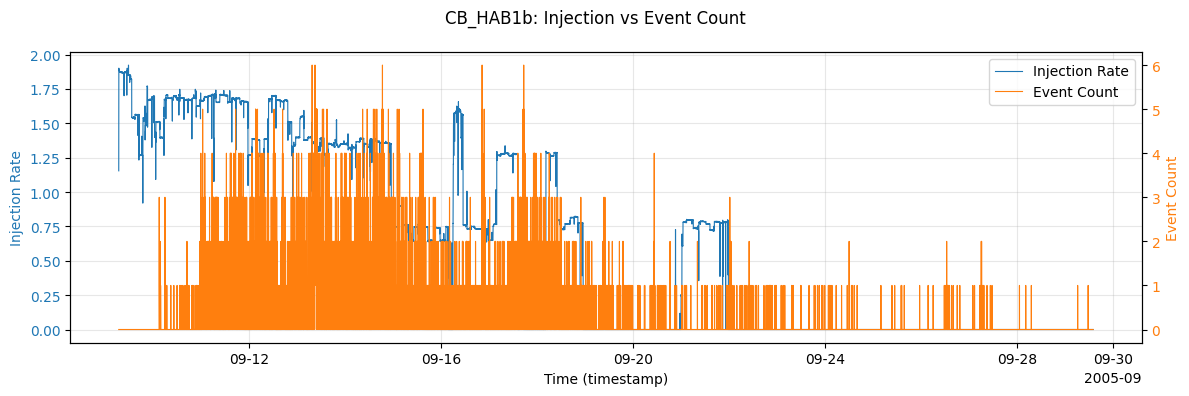

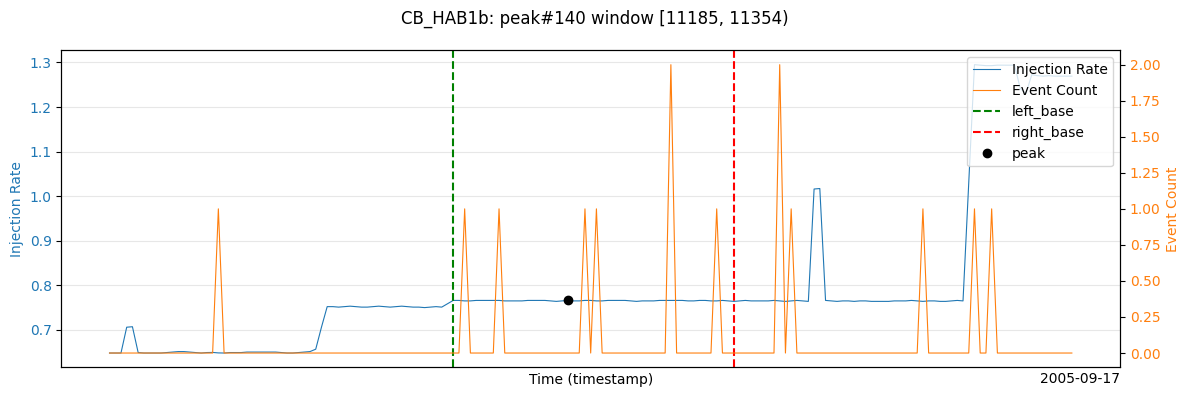

In [33]:
plot_global_overlay(RESOLVED_DATASET, series, metadata=catalog_ds.metadata)
plot_peak_window(RESOLVED_DATASET, series, peaks, peak_rank=140, offset=60, metadata=catalog_ds.metadata)


In [8]:
DATASETS_TO_COMPARE = ['ssfs']
EXPAND_REGION_MEMBERS = True
CATALOG_CFG = {
    'mag_completeness': -10,
    'normalize': True,
}
resolved_datasets = resolve_dataset_tokens(
    DATASETS_TO_COMPARE,
    expand_region_members=EXPAND_REGION_MEMBERS,
)
catalog_ds_dict = {}
for i,ds_name in enumerate(resolved_datasets):
    catalog_ds = load_catalog_flexible(ds_name, CATALOG_CFG)
    catalog_ds_dict[ds_name] = catalog_ds

Using registered catalog: SSFS1993-Standard
Using registered catalog: SSFS2000-Standard
Using registered catalog: SSFS2003-Standard
Using registered catalog: SSFS2004-Standard
Using registered catalog: SSFS2005-Standard


/root/autodl-tmp/em_eqf/src/data/sequence.py:345: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(


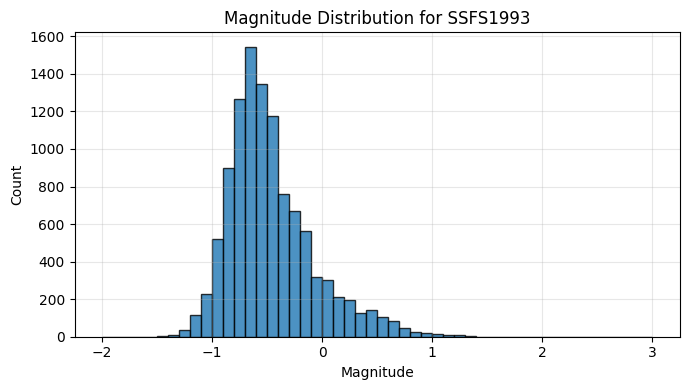

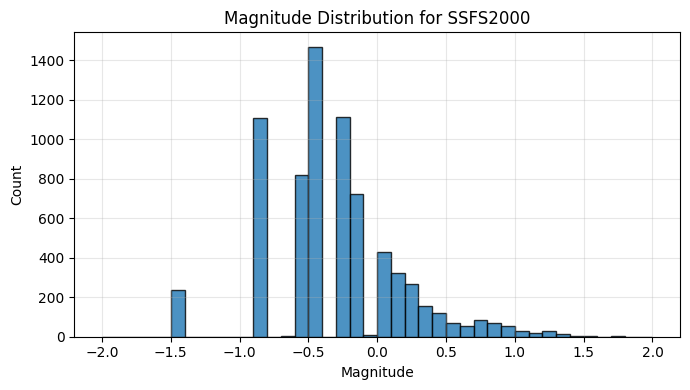

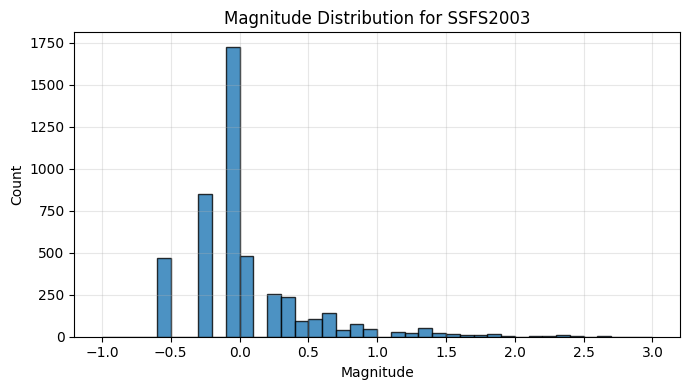

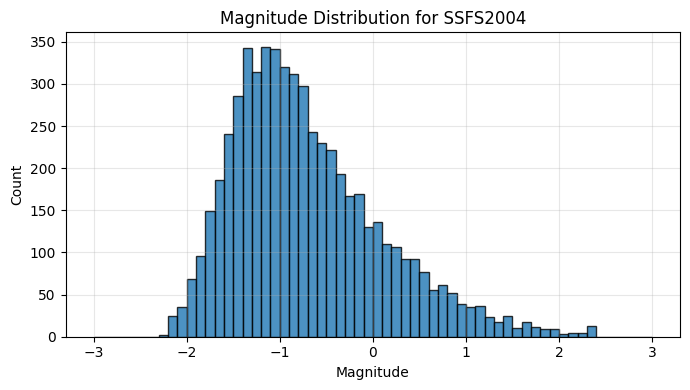

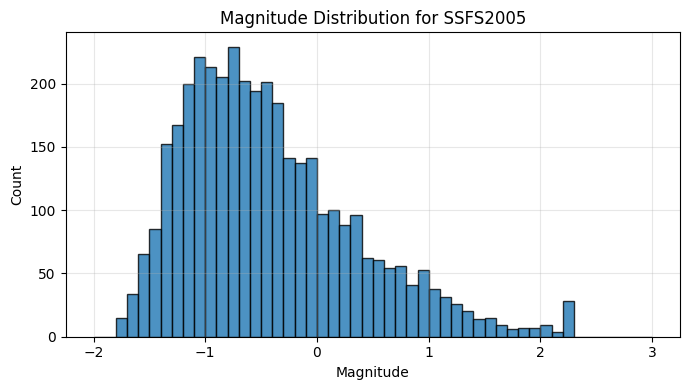

In [9]:
for ds_name in resolved_datasets:
    m = catalog_ds_dict[ds_name].full_sequence.mag
    mags = m.detach().cpu().numpy().reshape(-1) if hasattr(m, 'detach') else np.asarray(m).reshape(-1)
    mags = mags[np.isfinite(mags)]

    bin_width = 0.1
    bins = np.arange(np.floor(mags.min()), np.ceil(mags.max()) + bin_width, bin_width)

    plt.figure(figsize=(7, 4))
    plt.hist(mags, bins=bins, color='tab:blue', edgecolor='black', alpha=0.8)
    plt.xlabel('Magnitude')
    plt.ylabel('Count')
    plt.title('Magnitude Distribution for ' + ds_name)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 6) Batch Comparison

In [10]:
DATASETS_TO_COMPARE = [
    'FORGE2022',
    'St1-2020',
    'ssfs',
    'cb',
    'Basel',
]

EXPAND_REGION_MEMBERS = True  # True 时会把 ssfs/cb 展开成具体子数据集

resolved_datasets = resolve_dataset_tokens(
    DATASETS_TO_COMPARE,
    expand_region_members=EXPAND_REGION_MEMBERS,
)
print('Resolved datasets:', resolved_datasets)

compare_df, compare_cache = compare_datasets(
    datasets=resolved_datasets,
    catalog_cfg=CATALOG_CFG,
    peak_height=PEAK_HEIGHT,
    peak_min_distance=PEAK_MIN_DISTANCE,
)

compare_df

Resolved datasets: ['FORGE2022', 'St1-2020', 'SSFS1993', 'SSFS2000', 'SSFS2003', 'SSFS2004', 'SSFS2005', 'CB_HAB1a', 'CB_HAB1b', 'CB_HAB4', 'Basel']
Using registered catalog: FORGE2022-Standard


/root/autodl-tmp/em_eqf/src/data/sequence.py:345: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(


Using registered catalog: St1-2020-Standard
Using registered catalog: SSFS1993-Standard
Using registered catalog: SSFS2000-Standard
Using registered catalog: SSFS2003-Standard
Using registered catalog: SSFS2004-Standard
Using registered catalog: SSFS2005-Standard
Using registered catalog: CB_HAB1a-Standard
Using registered catalog: CB_HAB1b-Standard


/root/autodl-tmp/em_eqf/src/data/sequence.py:345: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(


Using registered catalog: CB_HAB4-Standard


/root/autodl-tmp/em_eqf/src/data/sequence.py:345: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(


Using registered catalog: Basel-Standard


,dataset,catalog_name,freq,n_events,duration,injection_sum,count_sum,count_to_injection_ratio,n_peaks,mag_completeness
0,FORGE2022,FORGE2022,1h,34908,188.550003,1638.550903,34908.0,21.304190,9,-10.0
1,CB_HAB1a,CB_HAB1a,1h,23285,1121.966553,19398.214844,23285.0,1.200368,225,-10.0
2,CB_HAB4,CB_HAB4,1h,20735,571.133362,36308.414062,20735.0,0.571080,118,-10.0
3,SSFS1993,SSFS1993,1h,10743,515.116638,5185.740234,10742.0,2.071450,42,-10.0
4,CB_HAB1b,CB_HAB1b,1h,8282,487.000000,17829.753906,8282.0,0.464504,185,-10.0
5,SSFS2000,SSFS2000,1h,7215,252.400009,4608.232422,7214.0,1.565459,22,-10.0
6,St1-2020,St1-2020,1h,6317,3416.533447,2880.829346,6317.0,2.192771,19,-10.0
7,SSFS2004,SSFS2004,1h,5753,405.516693,1655.488037,5752.0,3.474504,14,-10.0
8,SSFS2003,SSFS2003,1h,4728,1115.116699,5493.227051,4726.0,0.860332,56,-10.0
9,Basel,Basel,1h,3715,102414.351562,11527.287109,3715.0,0.322279,3,-10.0


## 7) Batch Export Plots for All Triple Datasets

In [11]:
TRIPLET_PLOT_OUTPUT_SUBDIR = 'analysis_plots'
CATALOG_CFG = {
    'mag_completeness': -10,
    'normalize': True,
}
triplet_plot_df = export_triplet_plots(
    datasets=triplet_datasets,
    catalog_cfg=CATALOG_CFG,
    peak_height=PEAK_HEIGHT,
    peak_min_distance=PEAK_MIN_DISTANCE,
    peak_rank=0,
    offset=60,
    output_subdir=TRIPLET_PLOT_OUTPUT_SUBDIR,
)
triplet_plot_df


/root/autodl-tmp/em_eqf/src/data/sequence.py:345: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(


Using registered catalog: Basel-Standard
Using registered catalog: CB_HAB1a-Standard
Using registered catalog: CB_HAB1b-Standard
Using registered catalog: CB_HAB4-Standard
Using registered catalog: FORGE2022-Standard
Using registered catalog: SSFS1993-Standard
Using registered catalog: SSFS2000-Standard
Using registered catalog: SSFS2003-Standard
Using registered catalog: SSFS2004-Standard
Using registered catalog: SSFS2005-Standard


/root/autodl-tmp/em_eqf/src/data/sequence.py:345: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(


Using registered catalog: St1-2018-Standard
Using registered catalog: St1-2020-Standard


,dataset,n_peaks,global_plot,peak_plot,magnitude_distribution_plot,output_dir
0,Basel,3,data/Basel/analysis_plots/Basel_global_overlay...,data/Basel/analysis_plots/Basel_peak_rank0_off...,data/Basel/analysis_plots/Basel_magnitude_dist...,data/Basel/analysis_plots
1,CB_HAB1a,225,data/CB_HAB1a/analysis_plots/CB_HAB1a_global_o...,data/CB_HAB1a/analysis_plots/CB_HAB1a_peak_ran...,data/CB_HAB1a/analysis_plots/CB_HAB1a_magnitud...,data/CB_HAB1a/analysis_plots
2,CB_HAB1b,185,data/CB_HAB1b/analysis_plots/CB_HAB1b_global_o...,data/CB_HAB1b/analysis_plots/CB_HAB1b_peak_ran...,data/CB_HAB1b/analysis_plots/CB_HAB1b_magnitud...,data/CB_HAB1b/analysis_plots
3,CB_HAB4,118,data/CB_HAB4/analysis_plots/CB_HAB4_global_ove...,data/CB_HAB4/analysis_plots/CB_HAB4_peak_rank0...,data/CB_HAB4/analysis_plots/CB_HAB4_magnitude_...,data/CB_HAB4/analysis_plots
4,FORGE2022,9,data/FORGE2022/analysis_plots/FORGE2022_global...,data/FORGE2022/analysis_plots/FORGE2022_peak_r...,data/FORGE2022/analysis_plots/FORGE2022_magnit...,data/FORGE2022/analysis_plots
5,SSFS1993,42,data/SSFS1993/analysis_plots/SSFS1993_global_o...,data/SSFS1993/analysis_plots/SSFS1993_peak_ran...,data/SSFS1993/analysis_plots/SSFS1993_magnitud...,data/SSFS1993/analysis_plots
6,SSFS2000,22,data/SSFS2000/analysis_plots/SSFS2000_global_o...,data/SSFS2000/analysis_plots/SSFS2000_peak_ran...,data/SSFS2000/analysis_plots/SSFS2000_magnitud...,data/SSFS2000/analysis_plots
7,SSFS2003,56,data/SSFS2003/analysis_plots/SSFS2003_global_o...,data/SSFS2003/analysis_plots/SSFS2003_peak_ran...,data/SSFS2003/analysis_plots/SSFS2003_magnitud...,data/SSFS2003/analysis_plots
8,SSFS2004,14,data/SSFS2004/analysis_plots/SSFS2004_global_o...,data/SSFS2004/analysis_plots/SSFS2004_peak_ran...,data/SSFS2004/analysis_plots/SSFS2004_magnitud...,data/SSFS2004/analysis_plots
9,SSFS2005,51,data/SSFS2005/analysis_plots/SSFS2005_global_o...,data/SSFS2005/analysis_plots/SSFS2005_peak_ran...,data/SSFS2005/analysis_plots/SSFS2005_magnitud...,data/SSFS2005/analysis_plots
